In [2]:
# import the library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
import warnings
warnings.filterwarnings('ignore')

In [3]:
# load the data

df = pd.read_csv(r'C:\Users\ASUS\Pictures\data\PracticeProjects\6\Synthetic_Financial_datasets_log.csv')

print(df.shape)
print(df.head())

(6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [4]:
# ── KPI METRICS ──────────────────────────────────────────────
total_txn  = len(df)
fraud_txn  = df['isFraud'].sum()
fraud_rate = round(100 * fraud_txn / total_txn, 2)

avg_fraud_amt    = round(df[df['isFraud']==1]['amount'].mean(), 2)
avg_nonfraud_amt = round(df[df['isFraud']==0]['amount'].mean(), 2)

tp = int(((df['isFlaggedFraud']==1) & (df['isFraud']==1)).sum())
fp = int(((df['isFlaggedFraud']==1) & (df['isFraud']==0)).sum())
fn = int(((df['isFlaggedFraud']==0) & (df['isFraud']==1)).sum())
tn = int(((df['isFlaggedFraud']==0) & (df['isFraud']==0)).sum())

precision = round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0
recall    = round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0
f1        = round(2 * precision * recall / (precision + recall), 4) if (precision + recall) > 0 else 0

print("Total TXN      :", total_txn)
print("Fraud TXN      :", fraud_txn)
print("Fraud Rate     :", fraud_rate, "%")
print("Avg Fraud Amt  :", avg_fraud_amt)
print("Avg Legit Amt  :", avg_nonfraud_amt)
print("Precision      :", precision)
print("Recall         :", recall)
print("F1 Score       :", f1)

Total TXN      : 6362620
Fraud TXN      : 8213
Fraud Rate     : 0.13 %
Avg Fraud Amt  : 1467967.3
Avg Legit Amt  : 178197.04
Precision      : 1.0
Recall         : 0.0019
F1 Score       : 0.0038


In [ ]:
# ── FRAUD BY TRANSACTION TYPE ─────────────────────────────────
by_type = (df.groupby(type)['isFraud']
             .agg(['sum','count'])
             .rename(columns={'sum':'fraud','count':'total'})
             .assign(rate=lambda x: round(100*x['fraud']/x['total'], 2))
             .sort_values('rate', ascending=True))

# ── AMOUNT BAND ───────────────────────────────────────────────
def amt_band(x):
    if x >= 1_000_000:  return '>=1M'
    elif x >= 100_000:  return '100K-1M'
    elif x >= 10_000:   return '10K-100K'
    else:               return '0-10K'

df['amount_band'] = df['amount'].apply(amt_band)
band_order = ['0-10K','10K-100K','100K-1M','>=1M']

by_band = (df.groupby('amount_band')['isFraud']
             .agg(['sum','count'])
             .rename(columns={'sum':'fraud','count':'total'})
             .assign(rate=lambda x: round(100*x['fraud']/x['total'], 2))
             .reindex(band_order))

# ── CASH_OUT + TRANSFER BY AMOUNT BAND ───────────────────────
ct = df[df['type'].isin(['CASH_OUT','TRANSFER'])]
ct_band = (ct.groupby(['type','amount_band'])['isFraud']
             .agg(['sum','count'])
             .rename(columns={'sum':'fraud','count':'total'})
             .assign(rate=lambda x: round(100*x['fraud']/x['total'], 2))
             .reset_index())

# ── AVG AMOUNT FRAUD VS LEGIT BY TYPE ────────────────────────
avg_by_type = df.groupby('type')['amount'].mean()
avg_fraud_type = (df[df['isFraud']==1]
                  .groupby('type')['amount'].mean()
                  .round(2))
avg_legit_type = (df[df['isFraud']==0]
                  .groupby('type')['amount'].mean()
                  .round(2))

# ── AVG AMOUNT FLAGGED VS NON FLAGGED ────────────────────────
avg_flagged = (df[df['isFraud']==1]
               .groupby('isFlaggedFraud')['amount']
               .mean().round(2))

# ── MISMATCH ANALYSIS ─────────────────────────────────────────
df['mismatch'] = (df['oldbalanceOrg'] - df['amount']).round(2) != df['newbalanceOrig'].round(2)

mismatch_fraud = df[df['isFraud']==1]['mismatch'].agg(['sum','count'])
mismatch_all   = df['mismatch'].agg(['sum','count'])

# ── FRAUD FLAGGED BY AMOUNT BAND ─────────────────────────────
flagged_band = (df[df['isFraud']==1]
                .groupby('amount_band')
                .agg(fraud_txn=('isFraud','count'),
                     flagged=('isFlaggedFraud','sum'))
                .assign(pct_flagged=lambda x: round(100*x['flagged']/x['fraud_txn'],2))
                .reindex(band_order))

print("All chart data computed ✅")

All chart data computed ✅


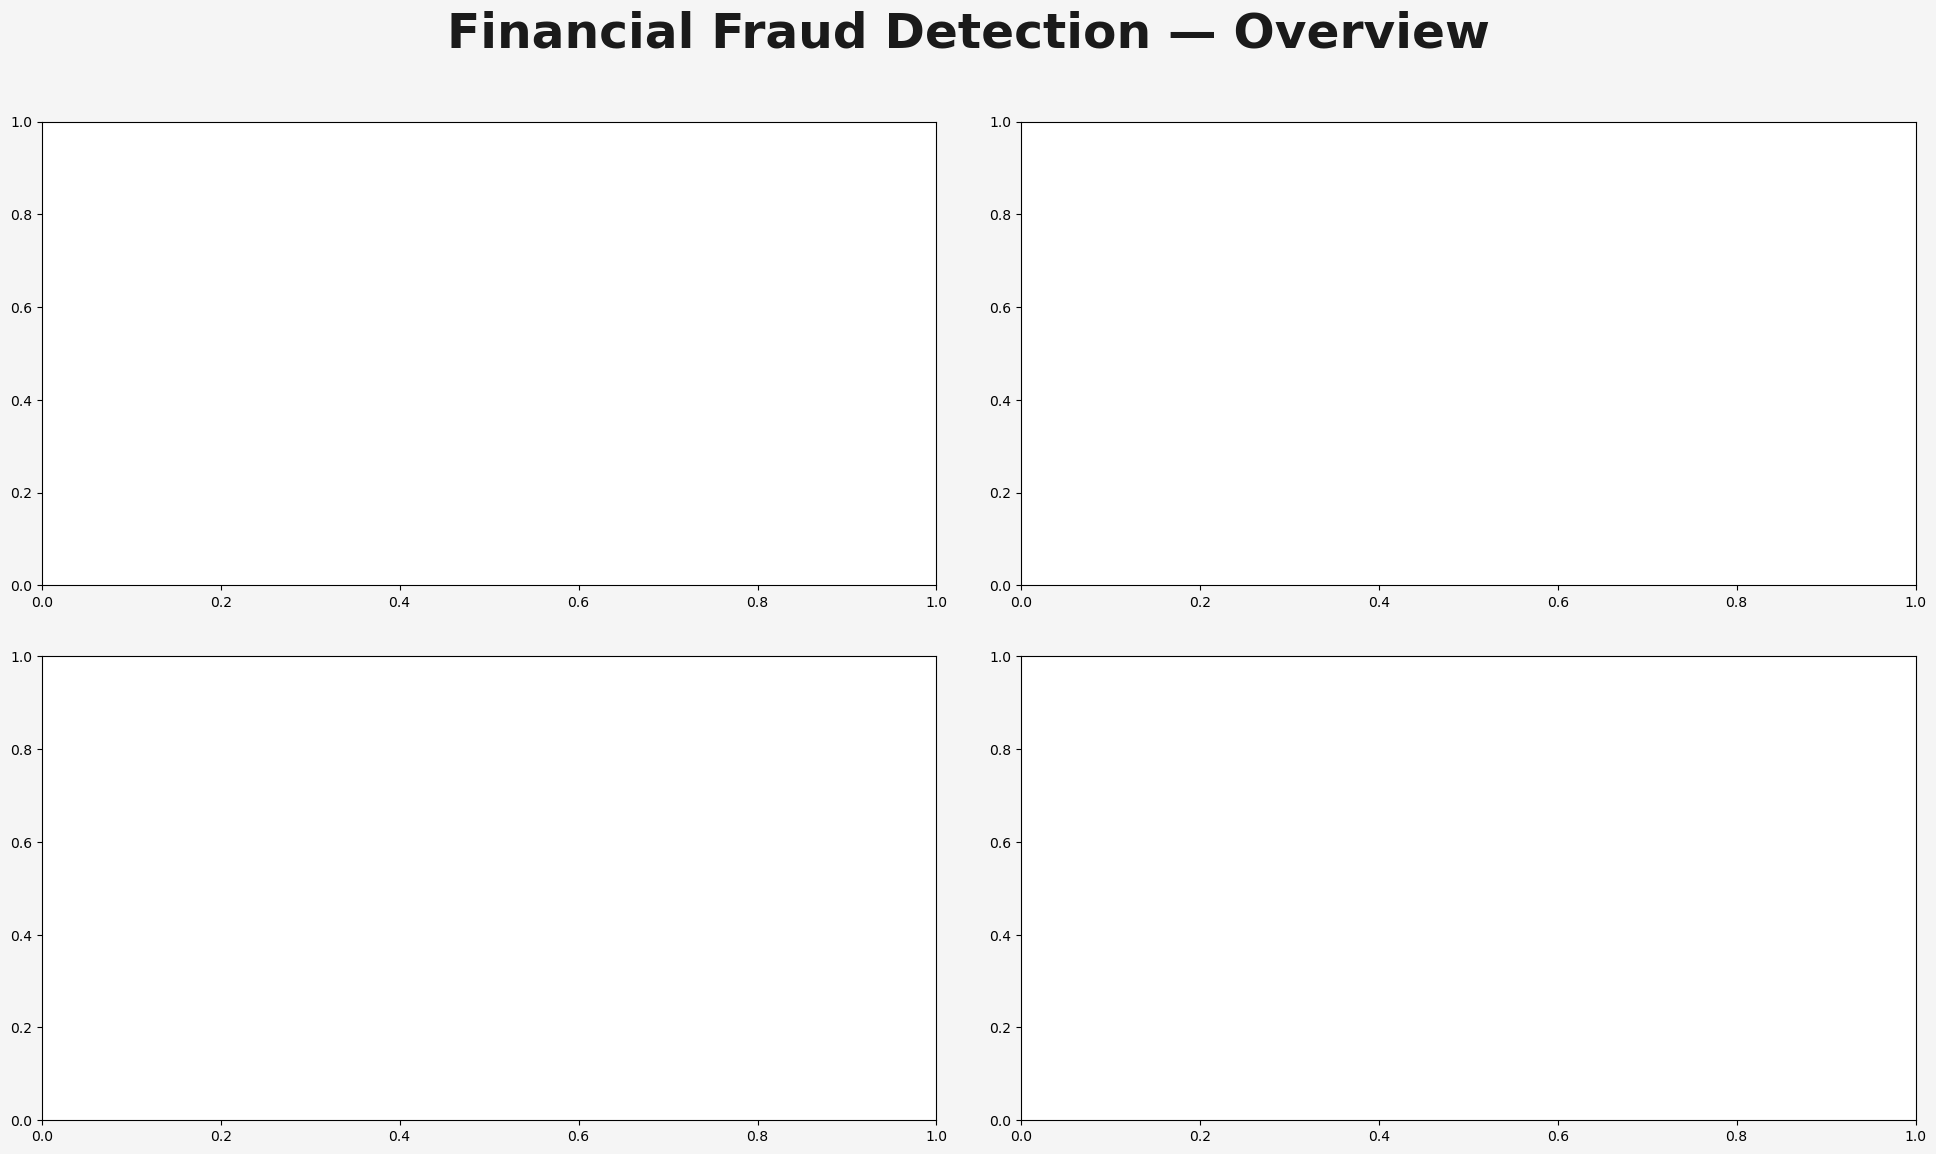

In [6]:
# ── COLOR PALETTE ─────────────────────────────────────────────
BG       = '#F5F5F5'
CARD     = '#FFFFFF'
BORDER   = '#E0E0E0'
TEXT     = '#1A1A1A'
SUBTEXT  = '#6B6B6B'
GRID     = '#EEEEEE'

FRAUD    = '#E63946'
LEGIT    = '#457B9D'
TRANSFER = '#F4A261'
CASHOUT  = '#2A9D8F'
HIGHLIGHT= '#E9C46A'
PURPLE   = '#9B5DE5'
MINT     = '#06D6A0'

# ── PAGE 1 FIGURE : TEST─────────────────────────────────────────────
fig1, axes = plt.subplots(2, 2, figsize=(20, 12))
fig1.patch.set_facecolor(BG)
fig1.suptitle('Financial Fraud Detection — Overview',
              fontsize=35, fontweight='bold',
              color=TEXT, y=0.98)

plt.tight_layout(pad=3.0)
plt.show()

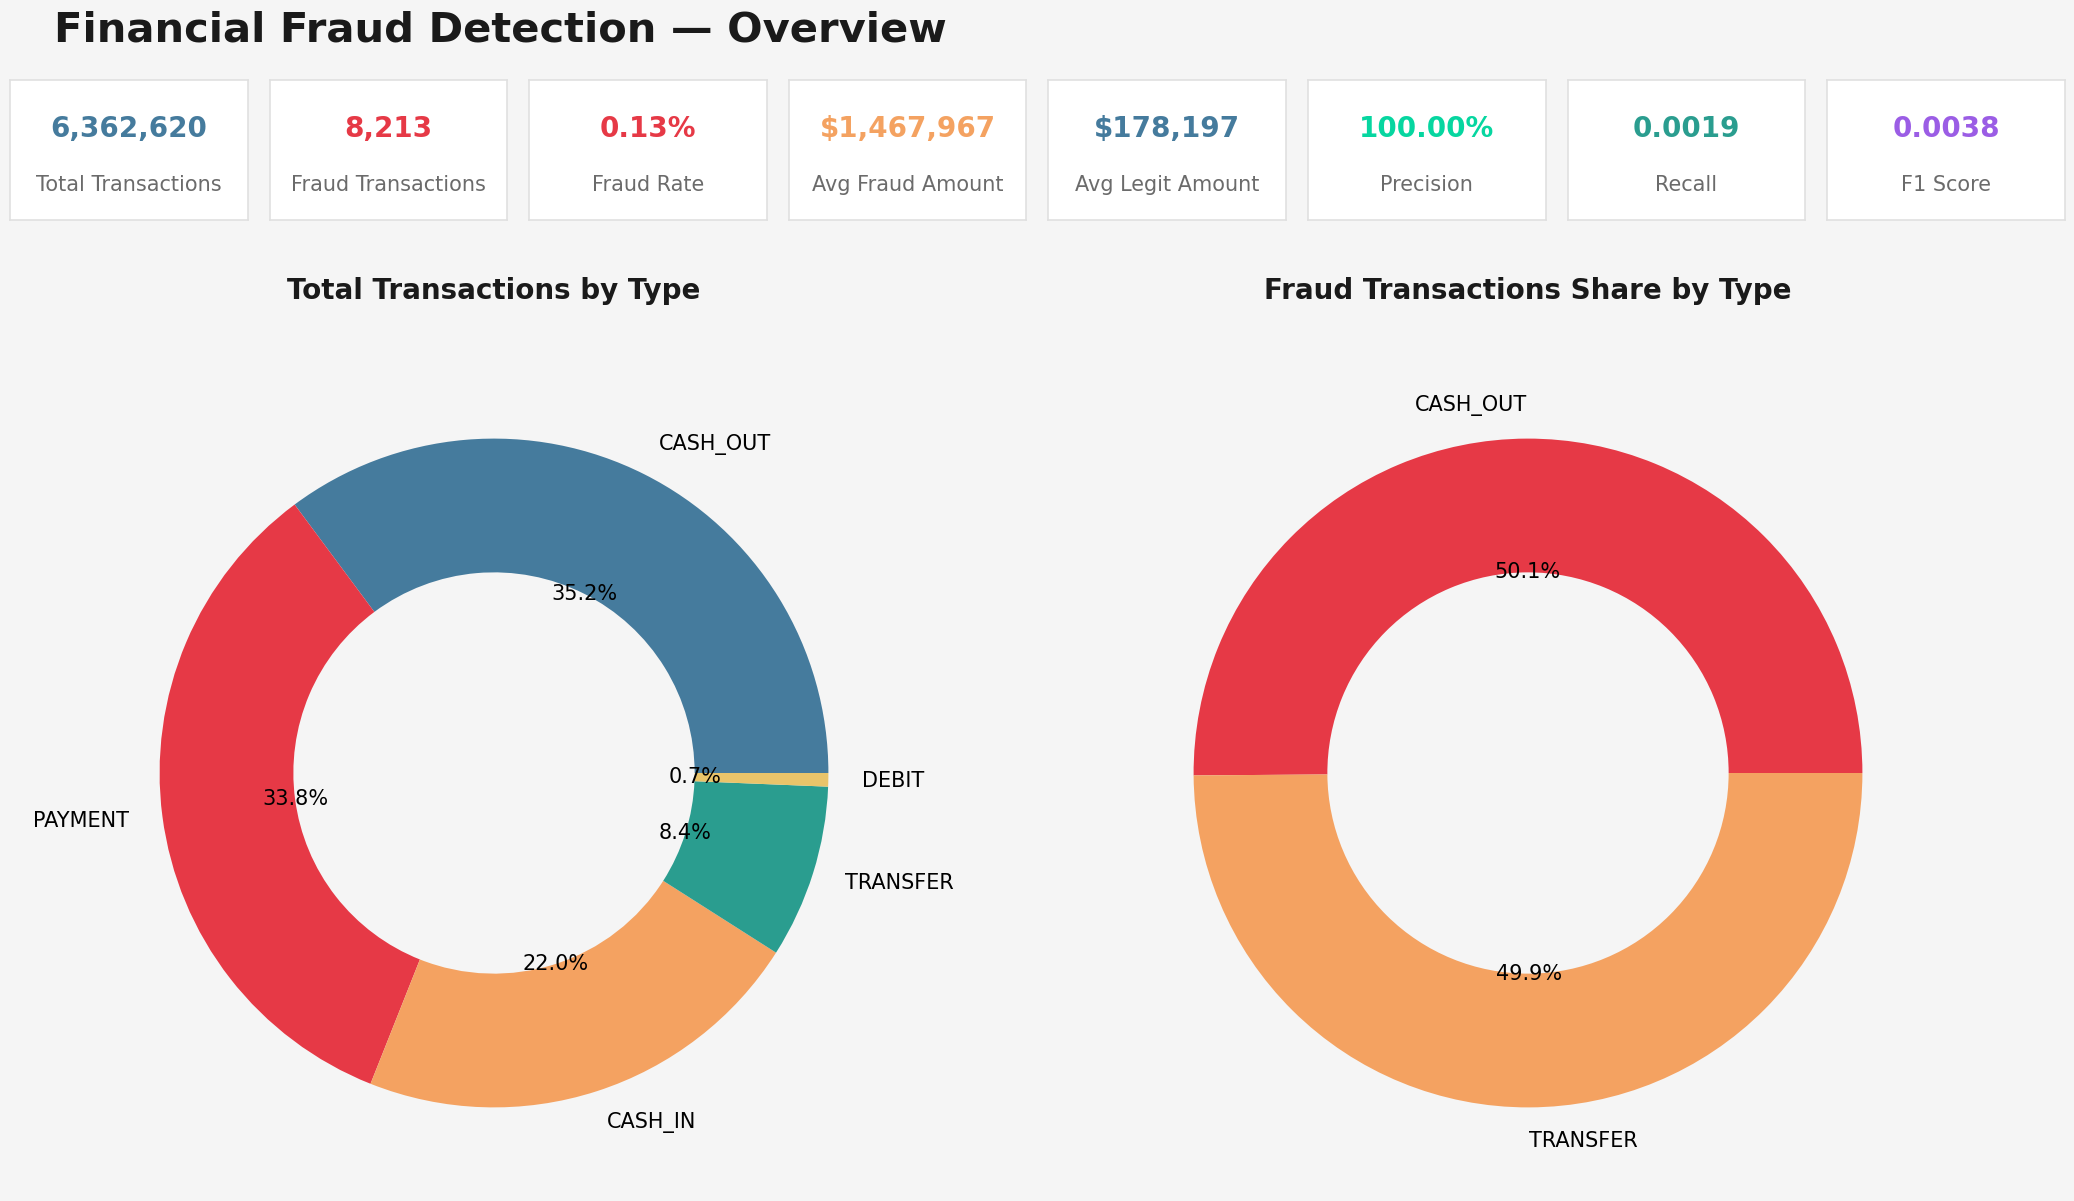

In [7]:
# ── FIGURE ────────────────────────────────────────────────────
fig1 = plt.figure(figsize=(22, 14))
fig1.patch.set_facecolor(BG)
fig1.text(0.04, 0.97, 'Financial Fraud Detection — Overview',
          fontsize=30, fontweight='bold', color=TEXT, va='top')

# ── KPI CARDS ─────────────────────────────────────────────────
kpis = [
    ('Total Transactions', f'{total_txn:,}',            LEGIT),
    ('Fraud Transactions', f'{fraud_txn:,}',            FRAUD),
    ('Fraud Rate',         f'{fraud_rate}%',            FRAUD),
    ('Avg Fraud Amount',   f'${avg_fraud_amt:,.0f}',    TRANSFER),
    ('Avg Legit Amount',   f'${avg_nonfraud_amt:,.0f}', LEGIT),
    ('Precision',          f'{precision:.2%}',          MINT),
    ('Recall',             f'{recall:.4f}',             CASHOUT),
    ('F1 Score',           f'{f1:.4f}',                 PURPLE),
]

for i, (label, value, color) in enumerate(kpis):
    ax = fig1.add_axes([0.02 + i*0.118, 0.82, 0.108, 0.10])
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)
        spine.set_linewidth(1.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, 0.65, value,
            ha='center', va='center',
            fontsize=20, fontweight='bold',
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, label,
            ha='center', va='center',
            fontsize=15, color=SUBTEXT,
            transform=ax.transAxes)

# ── DONUT 1 — Total TXN by Type ───────────────────────────────
ax1 = fig1.add_axes([0.05, 0.10, 0.38, 0.65])
ax1.pie(df['type'].value_counts(),
        labels=df['type'].value_counts().index,
        autopct='%1.1f%%',
        wedgeprops=dict(width=0.4),
        colors=[LEGIT, FRAUD, TRANSFER, CASHOUT, HIGHLIGHT],
        textprops=dict(fontsize=15))
ax1.set_title('Total Transactions by Type',
              fontsize=20, fontweight='bold', color=TEXT, pad=40)

# ── DONUT 2 — Fraud TXN Share by Type ─────────────────────────
ax2 = fig1.add_axes([0.52, 0.10, 0.38, 0.65])
ax2.pie(df[df['isFraud']==1]['type'].value_counts(),
        labels=df[df['isFraud']==1]['type'].value_counts().index,
        autopct='%1.1f%%',
        wedgeprops=dict(width=0.4),
        colors=[FRAUD, TRANSFER],
        textprops=dict(fontsize=15))
ax2.set_title('Fraud Transactions Share by Type',
              fontsize=20, fontweight='bold', color=TEXT, pad=40)

plt.show()

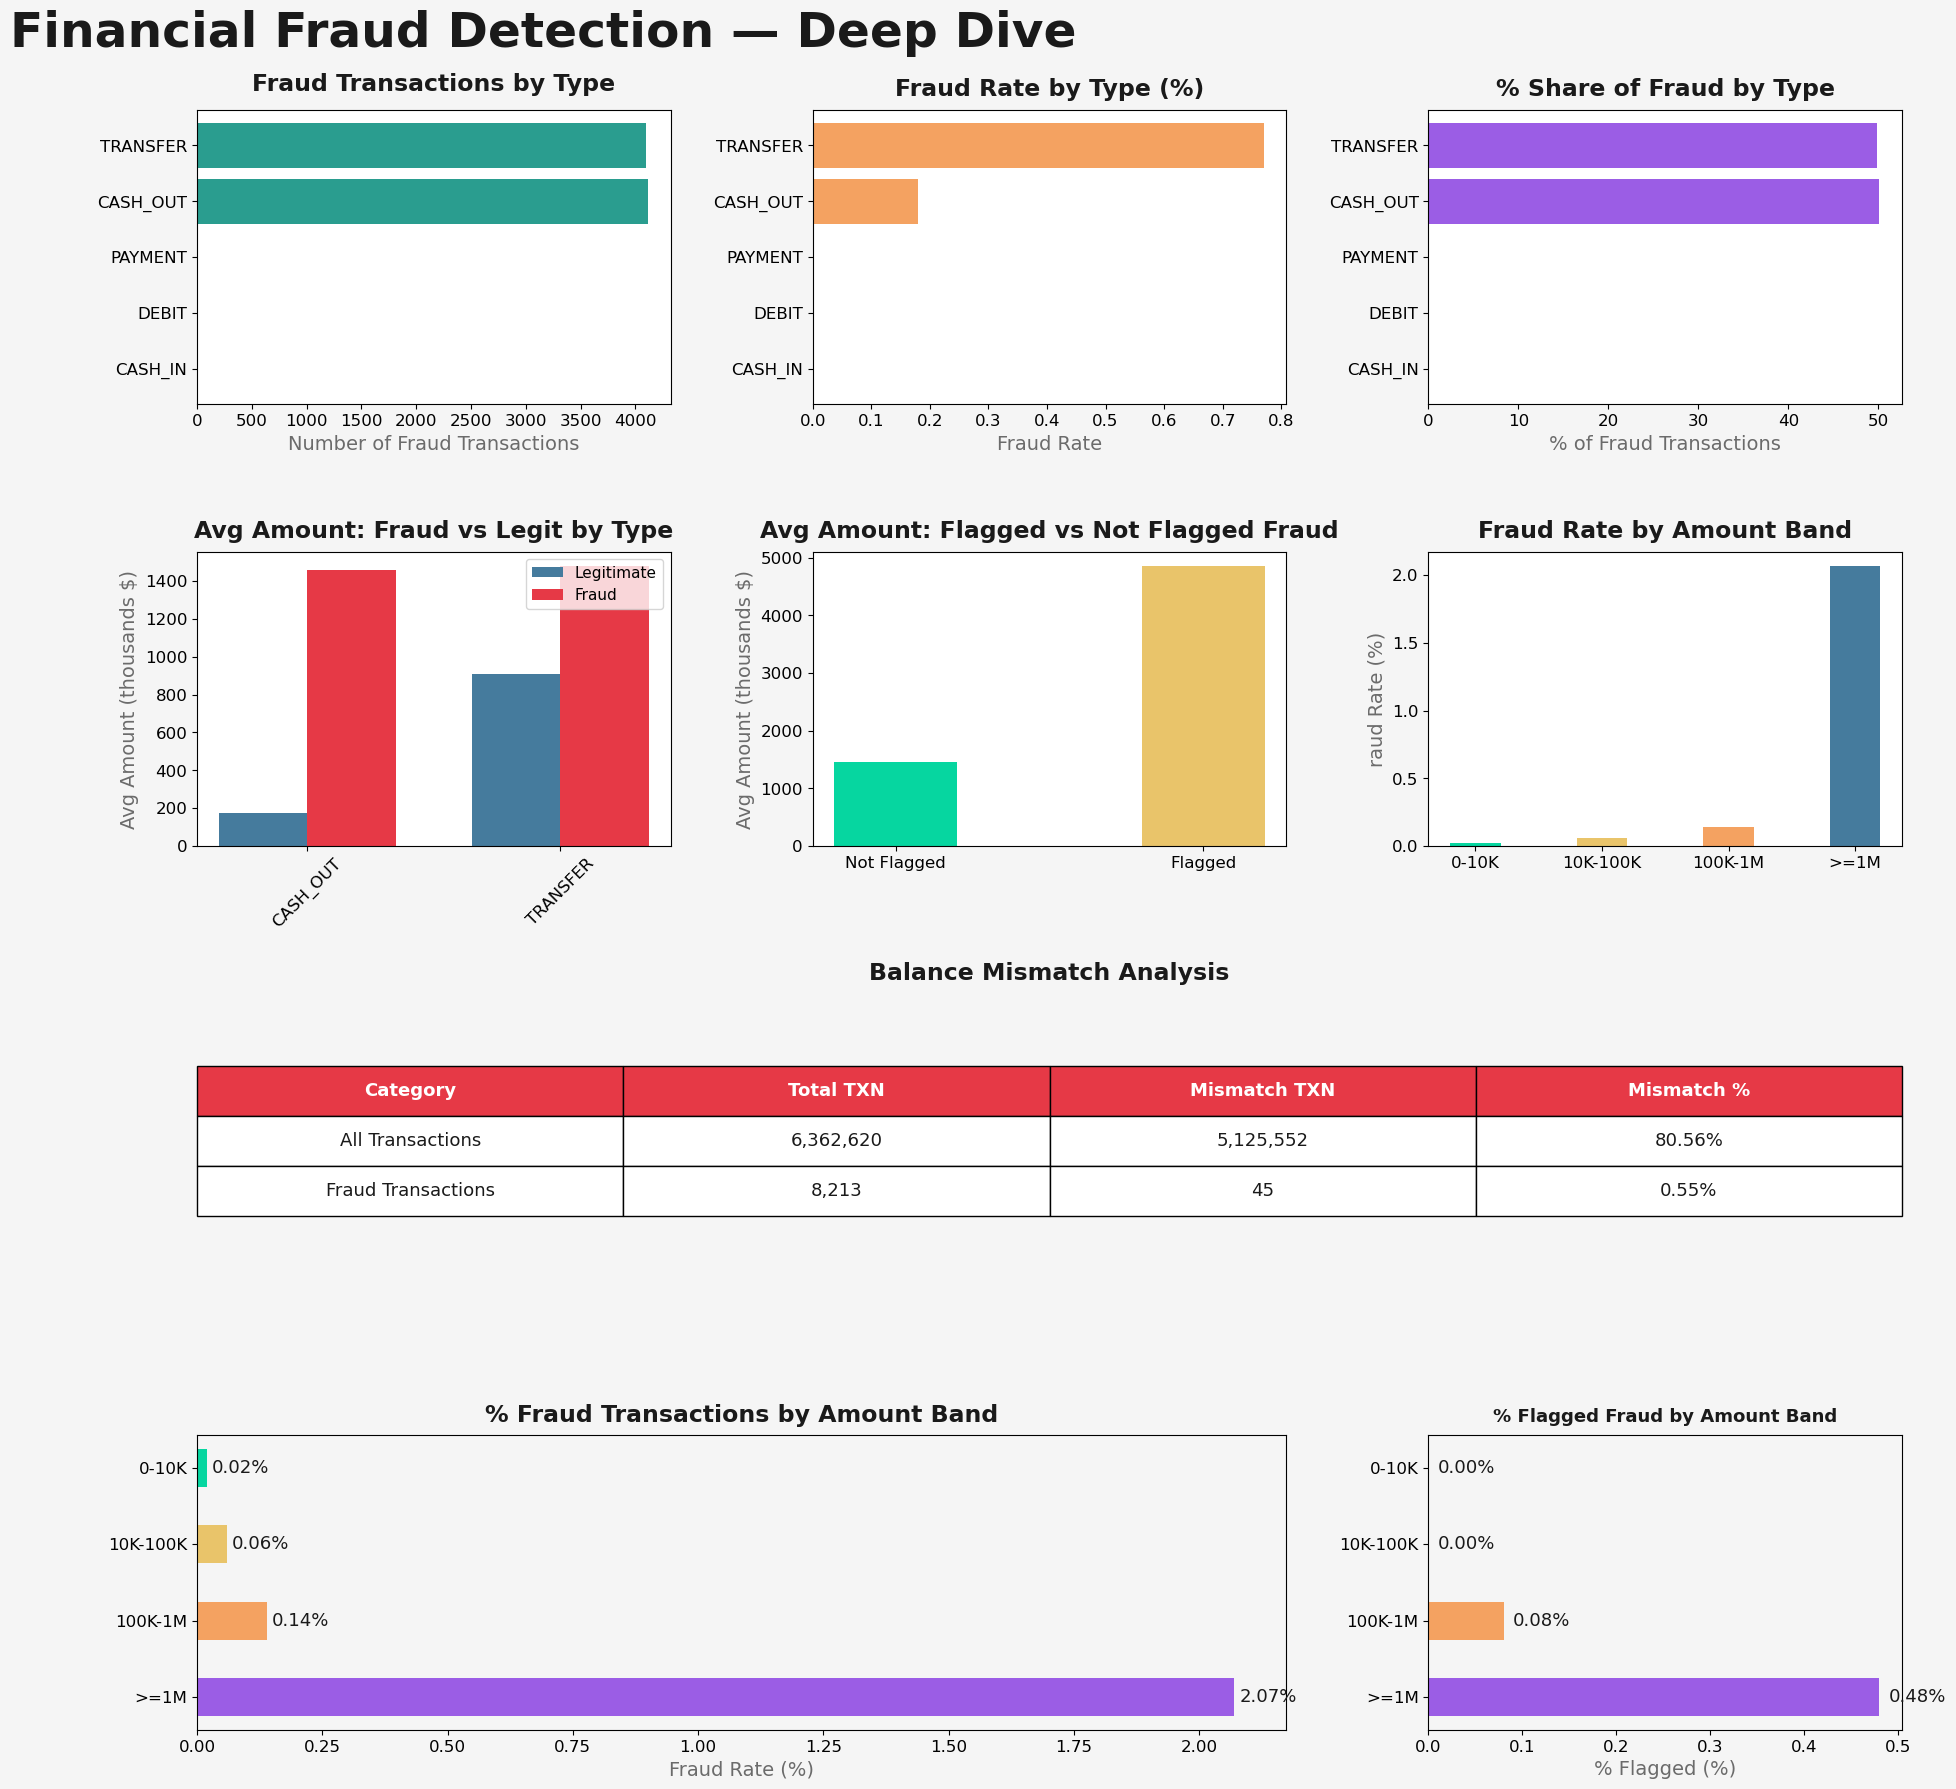

In [46]:
import matplotlib.gridspec as gridspec

# ── PAGE 2 FIGURE : TEST─────────────────────────────────────────────
fig2 = plt.figure(figsize=(22, 20))
fig2.patch.set_facecolor(BG)
fig2.text(0.04, 0.97, 'Financial Fraud Detection — Deep Dive',
              fontsize=35, fontweight='bold',
              color=TEXT, va='top')

gs = gridspec.GridSpec(4, 3, figure=fig2,
                       top=0.92,
                       hspace=0.5, 
                       wspace=0.3)

# Chart 1
ax = fig2.add_subplot(gs[0, 0])
ax.barh(by_type.index, by_type['fraud'], color=CASHOUT)
ax.set_title('Fraud Transactions by Type', fontsize=17, fontweight='bold', color=TEXT, pad=14)
ax.set_xlabel('Number of Fraud Transactions', fontsize=14, color=SUBTEXT)
ax.tick_params(axis='both', labelsize=12)

# Chart 2
ax = fig2.add_subplot(gs[0, 1])
ax.barh(by_type.index, by_type['rate'], color=TRANSFER)
ax.set_title('Fraud Rate by Type (%)', fontsize=17, fontweight='bold', color=TEXT, pad=10)
ax.set_xlabel('Fraud Rate', fontsize=14, color=SUBTEXT)
ax.tick_params(axis='both', labelsize=12)

# Chart 3
ax = fig2.add_subplot(gs[0, 2])
ax.barh(by_type.index, 100.0 * by_type['fraud'] / by_type['fraud'].sum(), color=PURPLE)
ax.set_title('% Share of Fraud by Type', fontsize=17, fontweight='bold', color=TEXT, pad=10)
ax.set_xlabel('% of Fraud Transactions', fontsize=14, color=SUBTEXT)
ax.tick_params(axis='both', labelsize=12)

# Only keep types that exist in both
common_types = avg_fraud_type.index
avg_legit_aligned = avg_legit_type.reindex(common_types)
x = np.arange(len(common_types))
width = 0.35
ax = fig2.add_subplot(gs[1, 0])
ax.bar(x - width/2, avg_legit_aligned/1000, width, color=LEGIT, label='Legitimate')
ax.bar(x + width/2, avg_fraud_type/1000, width, color=FRAUD, label='Fraud')
ax.set_xticks(x)
ax.set_xticklabels(common_types, rotation=45, fontsize=12)
ax.set_title('Avg Amount: Fraud vs Legit by Type', fontsize=17, fontweight='bold', color=TEXT, pad=10)
ax.set_ylabel('Avg Amount (thousands $)', fontsize=14, color=SUBTEXT)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=11)

ax = fig2.add_subplot(gs[1, 1])
labels = ['Not Flagged', 'Flagged']
values = avg_flagged.values
ax.bar(labels, values/1000, 
       color=[MINT, HIGHLIGHT], 
       width=0.4)
ax.set_title('Avg Amount: Flagged vs Not Flagged Fraud', 
             fontsize=17, fontweight='bold', color=TEXT, pad=10)
ax.set_ylabel('Avg Amount (thousands $)', fontsize=14, color=SUBTEXT)
ax.tick_params(axis='both', labelsize=12)

ax = fig2.add_subplot(gs[1, 2])
labels = band_order
values = by_band['rate'].values
ax.bar(labels, values, 
       color=[MINT, HIGHLIGHT, TRANSFER, LEGIT], 
       width=0.4)
ax.set_title('Fraud Rate by Amount Band', 
             fontsize=17, fontweight='bold', color=TEXT, pad=10)
ax.set_ylabel('raud Rate (%)', fontsize=14, color=SUBTEXT)
ax.tick_params(axis='both', labelsize=12)

# ── ROW 2 — MISMATCH TABLE (FULL WIDTH) ──────────────────────
ax = fig2.add_subplot(gs[2, 0:3])
ax.axis('off')
ax.set_facecolor(BG)

table_data = [
    ['All Transactions',   
     f"{mismatch_all['count']:,}",   
     f"{mismatch_all['sum']:,}",   
     f"{100*mismatch_all['sum']/mismatch_all['count']:.2f}%"],
    ['Fraud Transactions', 
     f"{mismatch_fraud['count']:,}",   
     f"{mismatch_fraud['sum']:,}",   
     f"{100*mismatch_fraud['sum']/mismatch_fraud['count']:.2f}%"],
]

col_labels = ['Category', 'Total TXN', 'Mismatch TXN', 'Mismatch %']

table = ax.table(cellText=table_data,
                 colLabels=col_labels,
                 loc='center',
                 cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 3)

# Style header row
for j in range(4):
    table[0, j].set_facecolor(FRAUD)
    table[0, j].set_text_props(color='white', fontweight='bold')

# Style data rows
for i in range(1, 3):
    for j in range(4):
        table[i, j].set_facecolor(CARD)
        table[i, j].set_text_props(color=TEXT)

ax.set_title('Balance Mismatch Analysis', 
             fontsize=17, fontweight='bold', 
             color=TEXT, pad=10)


# ── ROW 3 — BOTH FUNNELS SIDE BY SIDE ────────────────────────
ax1 = fig2.add_subplot(gs[3, 0:2])
ax1.set_facecolor(BG)

funnel_vals = by_band['rate'].reindex(band_order).values
bar_colors = [MINT, HIGHLIGHT, TRANSFER, PURPLE]

for i, (val, label, color) in enumerate(zip(funnel_vals, band_order, bar_colors)):
    ax1.barh(label, val, color=color, height=0.5)
    ax1.text(val + 0.01, i, f'{val:.2f}%',
             va='center', fontsize=13, color=TEXT)

ax1.set_title('% Fraud Transactions by Amount Band',
              fontsize=17, fontweight='bold', color=TEXT, pad=10)
ax1.set_xlabel('Fraud Rate (%)', fontsize=14, color=SUBTEXT)
ax1.tick_params(axis='both', labelsize=12)
ax1.invert_yaxis()


ax2 = fig2.add_subplot(gs[3, 2])
ax2.set_facecolor(BG)

flagged_vals = flagged_band['pct_flagged'].reindex(band_order).fillna(0).values

for i, (val, label, color) in enumerate(zip(flagged_vals, band_order, bar_colors)):
    ax2.barh(label, val, color=color, height=0.5)
    ax2.text(val + 0.01, i, f'{val:.2f}%',
             va='center', fontsize=13, color=TEXT)

ax2.set_title('% Flagged Fraud by Amount Band',
              fontsize=13, fontweight='bold', color=TEXT, pad=10)
ax2.set_xlabel('% Flagged (%)', fontsize=14, color=SUBTEXT)
ax2.tick_params(axis='both', labelsize=12)
ax2.invert_yaxis()

plt.tight_layout()
plt.show(block=True)


In [47]:
with PdfPages('Fraud_Detection_Dashboard.pdf') as pdf:
    pdf.savefig(fig1, bbox_inches='tight', facecolor=BG)
    pdf.savefig(fig2, bbox_inches='tight', facecolor=BG)

print("Dashboard saved ✅")

Dashboard saved ✅
